# Capas y conectividad entre especies

Tamaños de cluster de la capa química, componentes conexas y su relación con la
bioactividad positiva; conectividad entre especies por anotaciones y por drogas
compartidas.

Fuente: `analiceDB/01` y `02` de v3.

**Lee la capa química**: `01_edges_clusters_fingerprint.csv` pesa 941 MB, así que
la celda 2 tarda unos minutos. Salidas: `02_tamanos_cluster.csv`,
`02_componentes_conexas.csv`, `02_conectividad_anotaciones.csv`,
`02_conectividad_drogas.csv`.

## Imports

In [1]:
import sys, os
for _v in ("OMP_NUM_THREADS", "OPENBLAS_NUM_THREADS", "MKL_NUM_THREADS", "NUMEXPR_NUM_THREADS"):
    os.environ.setdefault(_v, "1")          # antes de numpy: un hilo por proceso

import numpy as np, pandas as pd
import matplotlib.pyplot as plt, seaborn as sns

V4 = "/home/ggiordano/TDR/TDR_2026_v4"
sys.path.insert(0, f"{V4}/comun")
sys.path.insert(0, f"{V4}/analiceDB")
%load_ext autoreload
%autoreload 2
import tdr, nucleo as nf
import funciones_analice as fa              # el .py de esta carpeta

SALIDAS = tdr.out("analiceDB")
FIGURAS = SALIDAS / "figuras"
NB      = "02"                             # numero de este notebook: prefija todo lo que genere
n_core  = 20

plt = tdr.estilo()
SALIDAS

PosixPath('/home/ggiordano/TDR/TDR_2026_v4/gon4/analiceDB_out')

## Datos

In [2]:
datos = tdr.cargar_db(anotaciones=True, quimica=True, cluster_consistent=False)
len(datos.tclus), len(datos.ddt), len(datos.sclus), len(datos.dds)

· 00_specie_target
· 03_bioactivities_target_compound
· 04a_interpro / 04b_orthomcl
· 01/02 clusters y aristas quimicas (pesado)


(2396103, 42911645, 2396103, 973)

## Acondicionamiento

133456 clusters con bioactividad positiva de 2261893
  figura -> /home/ggiordano/TDR/TDR_2026_v4/gon4/analiceDB_out/figuras/02_f01_tamanos_cluster.pdf


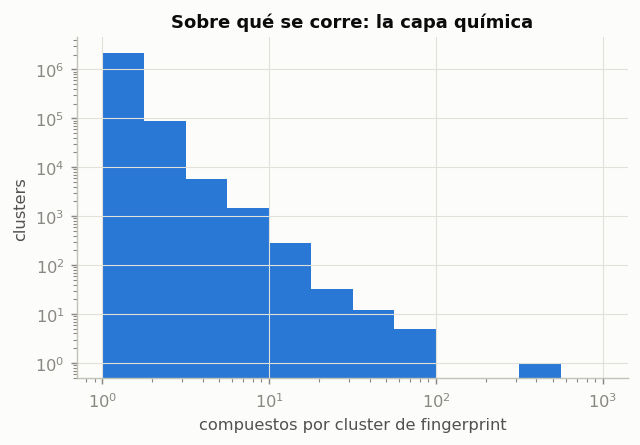

In [15]:
# clusters de fingerprint con alguna punta de bioactividad positiva
posdt_fp = (datos.posdt.merge(datos.tclus.rename(columns={"drug": "drug_id"}),
                              on="drug_id", how="left")[["cluster_id", "target_id"]]
            .drop_duplicates())
con_bioact = set(posdt_fp["cluster_id"].dropna())
print(f"{len(con_bioact)} clusters con bioactividad positiva de {datos.tclus['cluster_id'].nunique()}")

fig, ax = plt.subplots(figsize=(5, 3.5), tight_layout=True)
tam = fa.tamanos_de_cluster(datos.tclus)
ax.hist(tam["tamano"], bins=np.logspace(0, 3, 13), color=tdr.S1)
ax.set_xscale("log"); ax.set_yscale("log")
ax.set_xlabel("compuestos por cluster de fingerprint")
ax.set_ylabel("clusters")
ax.set_title("Sobre qué se corre: la capa química")
tdr.guardar(fig, f"{NB}_f01_tamanos_cluster", FIGURAS)

## Corrida

In [4]:
# celda de corrida: el ciclo se lee aca
tam_fp = fa.tamanos_de_cluster(datos.tclus).assign(capa="fingerprint")
tam_se = fa.tamanos_de_cluster(datos.sclus).assign(capa="subestructura")
comp   = fa.componentes_conexas(datos.ddt, con_bioact)
con_ann = fa.conectividad_entre_especies(datos, por="anotaciones")
con_drg = fa.conectividad_entre_especies(datos, por="drogas")

pd.concat([tam_fp, tam_se]).to_csv(SALIDAS / f"{NB}_tamanos_cluster.csv", index=False)
comp.to_csv(SALIDAS / f"{NB}_componentes_conexas.csv", index=False)
con_ann.to_csv(SALIDAS / f"{NB}_conectividad_anotaciones.csv")
con_drg.to_csv(SALIDAS / f"{NB}_conectividad_drogas.csv")
fa.escribir_meta(SALIDAS, NB, notebook="02_capas_y_conectividad.ipynb",
                 params={"quimica": True, "cluster_consistent": False})

  meta -> /home/ggiordano/TDR/TDR_2026_v4/gon4/analiceDB_out/02_meta.json


{'notebook': '02_capas_y_conectividad.ipynb',
 'nb': '02',
 'fecha': '2026-09-07 10:19',
 'params': {'quimica': True, 'cluster_consistent': False},
 'n_core': None,
 'tablas_db': {'00_specie_target.csv': '2026-06-05',
  '00_specie_target_full.csv': '2026-06-05',
  '01_clusters_fingerprint.csv': '2026-05-13',
  '01_deleted_compounds.csv': '2026-05-13',
  '01_edges_clusters_fingerprint.csv': '2026-05-13',
  '02_clusters_subestructure.csv': '2026-05-13',
  '02_edges_clusters_subestructure.csv': '2026-05-13',
  '03_bioactivities_organism_compound.csv': '2026-06-04',
  '03_bioactivities_target_compound.csv': '2026-08-07',
  '04a_interpro.csv': '2026-06-10',
  '04b_orthomcl.csv': '2026-08-25'},
 'python': '3.12.2',
 'pandas': '2.2.3'}

# Resultados

In [5]:
comp    = pd.read_csv(SALIDAS / f"{NB}_componentes_conexas.csv")
con_ann = pd.read_csv(SALIDAS / f"{NB}_conectividad_anotaciones.csv", index_col=0)
con_drg = pd.read_csv(SALIDAS / f"{NB}_conectividad_drogas.csv", index_col=0)

n   = comp["total_clusters"].sum()
con = comp.loc[comp["clusters_con_bioact"] > 0, "total_clusters"].sum()
print(f"nodos en componentes con bioactividad: {con} ({con/n:.2%})")
print(f"nodos en componentes sin bioactividad: {n-con} ({(n-con)/n:.2%})")
comp.describe()

nodos en componentes con bioactividad: 724974 (41.18%)
nodos en componentes sin bioactividad: 1035474 (58.82%)


,componente,total_clusters,clusters_con_bioact
count,192742.000000,192742.000000,192742.000000
mean,96370.500000,9.133702,0.460683
std,55639.967129,318.482004,8.727678
min,0.000000,1.000000,0.000000
25%,48185.250000,2.000000,0.000000
50%,96370.500000,3.000000,0.000000
75%,144555.750000,6.000000,0.000000
max,192741.000000,137050.000000,2818.000000


  figura -> /home/ggiordano/TDR/TDR_2026_v4/gon4/analiceDB_out/figuras/02_f02_componentes_conexas.pdf


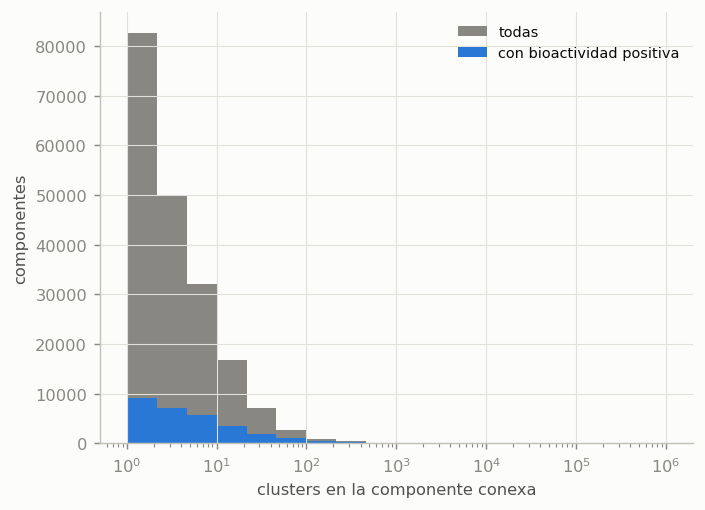

In [16]:
fig, ax = plt.subplots(figsize=(5.5, 4), tight_layout=True)
bins = np.logspace(0, 6, 19)
ax.hist(comp["total_clusters"], bins=bins, color=tdr.MUTED, label="todas")
ax.hist(comp.loc[comp["clusters_con_bioact"] > 0, "total_clusters"], bins=bins,
        color=tdr.S1, label="con bioactividad positiva")
ax.set_xscale("log")
ax.set_xlabel("clusters en la componente conexa")
ax.set_ylabel("componentes")
ax.legend(fontsize=8)
tdr.guardar(fig, f"{NB}_f02_componentes_conexas", FIGURAS)

  figura -> /home/ggiordano/TDR/TDR_2026_v4/gon4/analiceDB_out/figuras/02_f03_conectividad_anotaciones.pdf


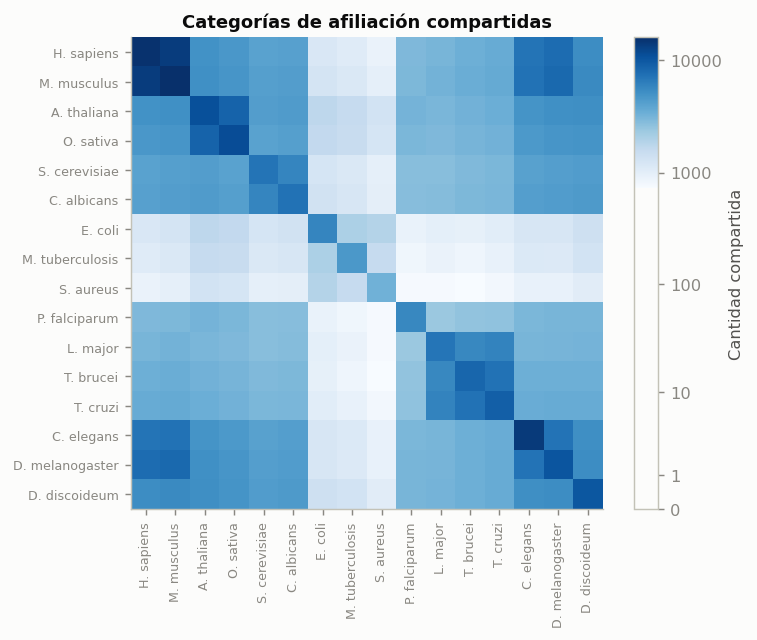

In [23]:
fig = fa.fig_conectividad(con_ann, plt, "Categorías de afiliación compartidas")
tdr.guardar(fig, f"{NB}_f03_conectividad_anotaciones", FIGURAS)